In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.font_manager import FontProperties, fontManager

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"
bfont_path = "/usr/share/fonts/myFonts/arialbd.ttf"

plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_prop_7 = FontProperties(fname=font_path, size=7)
font_name = font_prop.get_name()
ifont_prop = FontProperties(fname=ifont_path)
ifont_prop_7 = FontProperties(fname=ifont_path, size=7)
ifont_prop_6 = FontProperties(fname=ifont_path, size=6.5)
bfont_prop = FontProperties(fname=bfont_path)
ifont_name = ifont_prop.get_name()

plt.rcParams["font.family"] = [font_name]

In [2]:
label = "pident_90"
base_folder = '/active-data/analysis_results/chr_pla/genus'
ml_root = os.path.join(base_folder, "machine_learning")
figure_fold = os.path.join(base_folder, "figures")
os.makedirs(figure_fold, exist_ok=True)

def get_abbreviation(text):
    words = text.split()
    return text.capitalize().replace('Typical ', '').capitalize().replace('Intermediate replicon', 'IR')
    #return "".join([w[0].upper() for w in words])

k_list = [3, 4, 5]
marker_map = {3: "^", 4: "s", 5: "p"}
linestyle_map = {"Linear SVM": "-", "Logistic Regression": "--", "Random Forest": ":"}
target_classes = ["intermediate replicon", "typical chromosome", "typical plasmid"]
class_color = {"intermediate replicon": "#32CD32", "typical chromosome": plt.cm.tab10(3), "typical plasmid": plt.cm.tab10(0)}
metric_names = ["precision", "recall", "f1-score"]
base_x = np.arange(len(metric_names))
offset = 0.12
cls_offset = [-offset, 0, offset]
xtick_labels = ["Precision", "Recall", "F1-score"]

dir_list = ["k3_no_size", "k4_no_size", "k5_no_size", "k3_with_size", "k4_with_size", "k5_with_size",]
model_names = ["Linear SVM", "Logistic Regression", "Random Forest"]

def collect_all_data(suffix: str):
    dataset = []
    for k in k_list:
        folder_name = f"k{k}_{suffix}"
        folder_path = os.path.join(ml_root, folder_name)
        for model in model_names:
            csv_path = os.path.join(folder_path, f"{model}_report.csv")
            if not os.path.exists(csv_path):
                print(f"Missing file: {csv_path}")
                continue
            df_report = pd.read_csv(csv_path, index_col=0)
            df_filtered = df_report.loc[target_classes]
            value_matrix = df_filtered[metric_names].values
            dataset.append({
                "k": k,
                "model": model,
                "marker": marker_map[k],
                "linestyle": linestyle_map[model],
                "values": value_matrix
            })
    return dataset

def draw_subplot(ax, data_list, plot_title):
    for entry in data_list:
        mk = entry["marker"]
        ls = entry["linestyle"]
        val_mat = entry["values"]
        for cls_idx, cls_name in enumerate(target_classes):
            color = class_color[cls_name]
            x_pos = base_x + cls_offset[cls_idx]
            y = val_mat[cls_idx, :]
            ax.plot(x_pos, y, color=color, linestyle=ls, lw=0.75, alpha=0.7)
            ax.scatter(x_pos, y, marker=mk, color=color, s=10, zorder=6)

    ax.set_xticks(base_x)
    ax.set_xticklabels(xtick_labels)
    ax.set_xlim(-0.35, 2.35)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score", labelpad=0)
    ax.set_title(plot_title)

In [3]:
def plot_group_curve(ax, exp_tag_list, curve_type="roc", title=""):
    ax.set_title(title, fontproperties=font_prop, pad=0)
    if curve_type == "roc":
        ax.plot([0,1],[0,1], lw=0.75, c="gray", ls="--")
        ax.set_xlabel("False Positive Rate", fontproperties=font_prop, labelpad=0)
        ax.set_ylabel("True Positive Rate", fontproperties=font_prop, labelpad=0)
    else:
        ax.set_xlabel("Recall", fontproperties=font_prop, labelpad=0)
        ax.set_ylabel("Precision", fontproperties=font_prop, labelpad=0)
    ax.set_xlim(-0.1,1.1)
    ax.set_ylim(-0.1,1.1)
    ax.tick_params(axis='x', pad=1)

    k_color_map = {3: "#1f77b4", 4: "#ff7f0e", 5: "#2ca02c"}

    for dname, mname, ls, k_val in exp_tag_list:
        if curve_type == "roc":
            csv_path = os.path.join(ml_root, dname, f"{mname}_ovr_roc_curve.csv")
        else:
            csv_path = os.path.join(ml_root, dname, f"{mname}_ovr_pr_curve.csv")
        if not os.path.exists(csv_path):
            continue
        df_curve = pd.read_csv(csv_path)
        
        target_df = df_curve[df_curve["class"] == "intermediate replicon"]
        if target_df.empty:
            continue

        c = k_color_map[k_val]
        if curve_type == "roc":
            ax.plot(target_df["fpr"], target_df["tpr"],
                    color=c, linestyle=ls, lw=0.75)
        else:
            ax.plot(target_df["recall"], target_df["precision"],
                    color=c, linestyle=ls, lw=0.75)

def plot_bar_separated(ax, exp_tag_list, metric_type="auc", title=""):
    ax.set_title(title, fontproperties=font_prop, pad=0)
    if metric_type == "auc":
        ax.set_ylabel("AUROC", fontproperties=font_prop, labelpad=0)
    else:
        ax.set_ylabel("AUPRC", fontproperties=font_prop, labelpad=0)
    ax.set_ylim(0, 1.1)

    k_color_map = {3: "#1f77b4", 4: "#ff7f0e", 5: "#2ca02c"}

    models_order = ["Linear SVM", "Logistic Regression", "Random Forest"]
    short_name = {"Linear SVM": 'Linear\nSVM', "Logistic Regression": 'Logistic\nregression', "Random Forest": 'Random\nforest'}
    bar_width = 0.18
    group_gap = 0.04
    x_base = np.arange(len(models_order))

    data_dict = {m: {} for m in models_order}
    for dname, mname, ls, k_val in exp_tag_list:
        if metric_type == "auc":
            metric_csv = os.path.join(ml_root, dname, f"{mname}_ovr_auc.csv")
        else:
            metric_csv = os.path.join(ml_root, dname, f"{mname}_ovr_ap.csv")
        if not os.path.exists(metric_csv):
            continue
        df_metric = pd.read_csv(metric_csv)
        row = df_metric[df_metric["class"] == "intermediate replicon"]
        if row.empty:
            continue
        val = row.iloc[:, 1].values[0]
        data_dict[mname][k_val] = (val, ls)

    offsets = [-(bar_width+group_gap), 0, (bar_width+group_gap)]
    k_list = [3, 4, 5]
    fill_alpha = 0.32

    for i, k in enumerate(k_list):
        shift = offsets[i]
        c = k_color_map[k]
        heights = []
        line_styles = []
        for m in models_order:
            rec = data_dict[m].get(k, (np.nan, "-"))
            heights.append(rec[0])
            line_styles.append(rec[1])

        for j, (x_pos, h, ls) in enumerate(zip(x_base + shift, heights, line_styles)):
            if np.isnan(h):
                continue
            ax.bar(x_pos, h, width=bar_width, fill=True, facecolor=c, alpha=fill_alpha, edgecolor="none")
            rect_x0 = x_pos - bar_width / 2
            rect_x1 = x_pos + bar_width / 2
            ax.plot([rect_x0, rect_x1, rect_x1, rect_x0, rect_x0],
                    [0, 0, h, h, 0], color=c, linestyle=ls, lw=0.75)

    ax.set_xticks(x_base)
    ax.set_xticklabels([short_name[name] for name in models_order], fontsize=6.5)
    ax.tick_params(axis='x', pad=1)

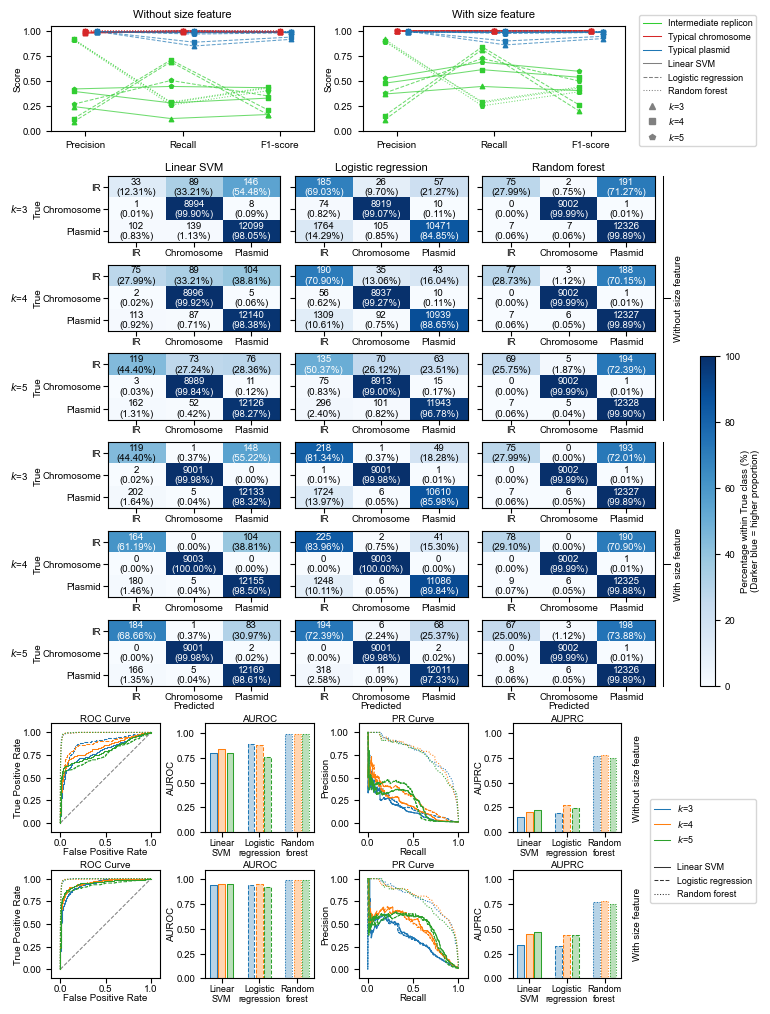

In [4]:
fig = plt.figure(figsize=(7.5, 7.5))

ax1 = fig.add_axes([0.055, 0.84, 0.35, 0.14])
ax2 = fig.add_axes([0.47, 0.84, 0.35, 0.14])

data_no_size = collect_all_data("no_size")
data_with_size = collect_all_data("with_size")

draw_subplot(ax1, data_no_size, "Without size feature")
draw_subplot(ax2, data_with_size, "With size feature")

label_name = {"Linear SVM": 'Linear SVM', "Logistic Regression": 'Logistic regression', "Random Forest": 'Random forest'}
legend_handles = []
for cls, c in class_color.items():
    abbr = get_abbreviation(cls)
    label_text = f"{cls.capitalize()}"
    legend_handles.append(Line2D([], [], color=c, lw=0.75, label=label_text))
for m, ls in linestyle_map.items():
    legend_handles.append(Line2D([], [], color="gray", linestyle=ls, lw=0.75, label=label_name[m]))
for k, mk in marker_map.items():
    legend_handles.append(Line2D([], [], marker=mk, color="gray", linestyle="", markersize=4, label=f"$k$={k}"))

fig.legend(handles=legend_handles, loc="upper right", ncol=1, bbox_to_anchor=(1.001, 1), frameon=True)

all_cm_info = []
for dname in dir_list:
    work_dir = os.path.join(ml_root, dname)
    for model in model_names:
        mat_csv = os.path.join(work_dir, f"{model}_confusion_matrix.csv")
        df_cm = pd.read_csv(mat_csv, index_col=0)
        cm_raw = df_cm.values
        row_sum = cm_raw.sum(axis=1, keepdims=True)
        row_sum[row_sum == 0] = 1
        cm_pct = cm_raw / row_sum * 100

        all_cm_info.append({
            "tag": f"{dname}\n{model}",
            "cm_raw": cm_raw,
            "cm_pct": cm_pct,
            "rows": df_cm.index.tolist(),
            "cols": df_cm.columns.tolist(),
            "dir_name": dname
        })

nrow = 6
ncol = 3
margin_left = 0.13
margin_right = 0.86
margin_top = 0.78
margin_bottom = 0.1
gap_x = 0.02
gap_y = 0.03

cell_w = (margin_right - margin_left - (ncol - 1)*gap_x) / ncol
cell_h = (margin_top - margin_bottom - (nrow - 1)*gap_y) / nrow
images = []
short_name = {"Linear SVM": 'Linear\nSVM', "Logistic Regression": 'Logistic\nregression', "Random Forest": 'Random\nforest'}

for idx, info in enumerate(all_cm_info):
    i_row = idx // ncol
    i_col = idx % ncol

    ax_left = margin_left + i_col*(cell_w + gap_x)
    ax_bottom = margin_bottom + (nrow - 1 - i_row)*(cell_h + gap_y)
    ax = fig.add_axes([ax_left, ax_bottom, cell_w, cell_h])

    if info is None:
        ax.axis("off")
        continue

    cm_raw = info["cm_raw"]
    cm_pct = info["cm_pct"]

    im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100, aspect="auto")
    images.append(im)

    if i_row == 0:
        ax.set_title(f'{label_name[model_names[i_col]]}', pad=4)
    else:
        ax.set_title("")

    abbr_rows = [get_abbreviation(s) for s in info["rows"]]
    abbr_cols = [get_abbreviation(s) for s in info["cols"]]
    ax.set_xticks(np.arange(len(info["cols"])))
    ax.set_yticks(np.arange(len(info["rows"])))
    ax.set_xticklabels(abbr_cols, rotation=0)
    ax.tick_params(axis='x', pad=1)
    if i_row == 5:
        ax.set_xlabel("Predicted", labelpad=0)
    if i_col == 0:
        ax.set_ylabel("True", labelpad=0)
        ax.set_yticklabels(abbr_rows)
        ax.tick_params(axis='y', pad=1)
    else:
        ax.set_yticklabels([])

    thresh = 50.0
    for i in range(cm_pct.shape[0]):
        for j in range(cm_pct.shape[1]):
            cnt = cm_raw[i, j]
            pct = cm_pct[i, j]
            text_str = f"{int(cnt)}\n({pct:.2f}%)"
            ax.text(j, i, text_str, ha="center", va="center", color="white" if pct > thresh else "black")

row_label_pos_y = []
for r in range(nrow):
    bot = margin_bottom + (nrow - 1 - r)*(cell_h + gap_y)
    mid_y = bot + cell_h/2
    row_label_pos_y.append(mid_y)

kmer_labels = ["$k$=3","$k$=4","$k$=5","$k$=3","$k$=4","$k$=5"]
for r, txt in enumerate(kmer_labels):
    fig.text(0.0, row_label_pos_y[r], txt, ha="left", va="center", fontproperties=font_prop)

side_label_y = [
    (row_label_pos_y[0]+row_label_pos_y[2])/2,
    (row_label_pos_y[3]+row_label_pos_y[5])/2
]

line_x_vert = margin_right + 0.01
line_x_text = line_x_vert + 0.01
lw = 0.75

y_top_nosize = row_label_pos_y[0]
y_bot_nosize = row_label_pos_y[2]
l1_nosize = Line2D([line_x_vert, line_x_vert],
                   [y_top_nosize + cell_h/2, y_bot_nosize - cell_h/2],
                   transform=fig.transFigure, color="black", linewidth=lw)
fig.add_artist(l1_nosize)

mid_y_nosize = (y_top_nosize + y_bot_nosize)/2
l2_nosize = Line2D([line_x_vert, line_x_text],
                   [mid_y_nosize, mid_y_nosize],
                   transform=fig.transFigure, color="black", linewidth=lw)
fig.add_artist(l2_nosize)

y_top_with = row_label_pos_y[3]
y_bot_with = row_label_pos_y[5]
l1_with = Line2D([line_x_vert, line_x_vert],
                 [y_top_with + cell_h/2, y_bot_with - cell_h/2],
                 transform=fig.transFigure, color="black", linewidth=lw)
fig.add_artist(l1_with)

mid_y_with = (y_top_with + y_bot_with)/2
l2_with = Line2D([line_x_vert, line_x_text],
                 [mid_y_with, mid_y_with],
                 transform=fig.transFigure, color="black", linewidth=lw)
fig.add_artist(l2_with)

fig.text(line_x_text + 0.005, side_label_y[0], "Without size feature", rotation=90, ha="left", va="center", fontproperties=font_prop)
fig.text(line_x_text + 0.005, side_label_y[1], "With size feature", rotation=90, ha="left", va="center", fontproperties=font_prop)

cbar_ax = fig.add_axes([0.92, margin_bottom, 0.02, 0.44])
cbar = fig.colorbar(images[0], cax=cbar_ax)
cbar.set_label("Percentage within True class (%)\n(Darker blue = higher proportion)", labelpad=0)

exp_info_no_size = [
    ("k3_no_size", "Random Forest", linestyle_map["Random Forest"], 3),
    ("k3_no_size", "Logistic Regression", linestyle_map["Logistic Regression"], 3),
    ("k3_no_size", "Linear SVM", linestyle_map["Linear SVM"], 3),
    ("k4_no_size", "Random Forest", linestyle_map["Random Forest"], 4),
    ("k4_no_size", "Logistic Regression", linestyle_map["Logistic Regression"], 4),
    ("k4_no_size", "Linear SVM", linestyle_map["Linear SVM"], 4),
    ("k5_no_size", "Random Forest", linestyle_map["Random Forest"], 5),
    ("k5_no_size", "Logistic Regression", linestyle_map["Logistic Regression"], 5),
    ("k5_no_size", "Linear SVM", linestyle_map["Linear SVM"], 5),
]
exp_info_with_size = [
    ("k3_with_size", "Random Forest", linestyle_map["Random Forest"], 3),
    ("k3_with_size", "Logistic Regression", linestyle_map["Logistic Regression"], 3),
    ("k3_with_size", "Linear SVM", linestyle_map["Linear SVM"], 3),
    ("k4_with_size", "Random Forest", linestyle_map["Random Forest"], 4),
    ("k4_with_size", "Logistic Regression", linestyle_map["Logistic Regression"], 4),
    ("k4_with_size", "Linear SVM", linestyle_map["Linear SVM"], 4),
    ("k5_with_size", "Random Forest", linestyle_map["Random Forest"], 5),
    ("k5_with_size", "Logistic Regression", linestyle_map["Logistic Regression"], 5),
    ("k5_with_size", "Linear SVM", linestyle_map["Linear SVM"], 5),
]

w_sub = 0.145
h_sub = 0.145
gap_w = 0.06
gap_h = 0.05
start_x = 0.055
top_row_y = -0.095
bottom_row_y = top_row_y - h_sub - gap_h

ax_roc_nosize    = fig.add_axes([start_x, top_row_y, w_sub, h_sub])
ax_bar_auc_nosize= fig.add_axes([start_x + w_sub + gap_w, top_row_y, w_sub, h_sub])
ax_pr_nosize     = fig.add_axes([start_x + 2*(w_sub + gap_w), top_row_y, w_sub, h_sub])
ax_bar_ap_nosize = fig.add_axes([start_x + 3*(w_sub + gap_w), top_row_y, w_sub, h_sub])

ax_roc_withsize    = fig.add_axes([start_x, bottom_row_y, w_sub, h_sub])
ax_bar_auc_withsize= fig.add_axes([start_x + w_sub + gap_w, bottom_row_y, w_sub, h_sub])
ax_pr_withsize     = fig.add_axes([start_x + 2*(w_sub + gap_w), bottom_row_y, w_sub, h_sub])
ax_bar_ap_withsize = fig.add_axes([start_x + 3*(w_sub + gap_w), bottom_row_y, w_sub, h_sub])

plot_group_curve(ax_roc_nosize, exp_info_no_size, curve_type="roc", title="ROC Curve")
plot_bar_separated(ax_bar_auc_nosize, exp_info_no_size, metric_type="auc", title="AUROC")
plot_group_curve(ax_pr_nosize, exp_info_no_size, curve_type="pr", title="PR Curve")
plot_bar_separated(ax_bar_ap_nosize, exp_info_no_size, metric_type="ap", title="AUPRC")

plot_group_curve(ax_roc_withsize, exp_info_with_size, curve_type="roc", title="ROC Curve")
plot_bar_separated(ax_bar_auc_withsize, exp_info_with_size, metric_type="auc", title="AUROC")
plot_group_curve(ax_pr_withsize, exp_info_with_size, curve_type="pr", title="PR Curve")
plot_bar_separated(ax_bar_ap_withsize, exp_info_with_size, metric_type="ap", title="AUPRC")


fig.text(start_x + 3*(w_sub + gap_w) + w_sub + 0.015, top_row_y + h_sub/2, "Without size feature", rotation=90, ha="left", va="center", fontproperties=font_prop)
fig.text(start_x + 3*(w_sub + gap_w) + w_sub + 0.015, bottom_row_y + h_sub/2, "With size feature", rotation=90, ha="left", va="center", fontproperties=font_prop)

k_color_map = {3: "#1f77b4", 4: "#ff7f0e", 5: "#2ca02c"}
models_order = ["Linear SVM", "Logistic Regression", "Random Forest"]
model_ls_dict = {
    "Random Forest": linestyle_map["Random Forest"],
    "Logistic Regression": linestyle_map["Logistic Regression"],
    "Linear SVM": linestyle_map["Linear SVM"],
}

legend_elements = []
for k in [3,4,5]:
    legend_elements.append(
        Line2D([], [], color=k_color_map[k], lw=0.75, label=f"$k$={k}")
    )
legend_elements.append(Line2D([], [], lw=0))
for m in models_order:
    ls = model_ls_dict[m]
    legend_elements.append(Line2D([], [], color="#333333", linestyle=ls, lw=0.75, label=f'{label_name[m]}'))

fig.legend(handles=legend_elements, loc="center right", bbox_to_anchor=(1.001, (top_row_y + h_sub + bottom_row_y)/2), frameon=True, handlelength=1.8)

rect = plt.Rectangle((0, 0), 1, 1, transform=fig.transFigure, facecolor='none', edgecolor='black', linewidth=2)
#fig.patches.append(rect)

figure_fold = f'{base_folder}/figures'
os.chdir(figure_fold)
plt.savefig(f"S_machine_learning_category_result.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"S_machine_learning_category_result.png", dpi=1000, bbox_inches="tight", transparent=True)

plt.show()